In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
import os

print(os.listdir('/content/drive'))

['MyDrive']


In [11]:
import os

print(os.path.exists('/content/drive/MyDrive'))

True


In [ ]:
import os
import shutil

source_folder = "/content/drive/MyDrive/final-year-research/datasets/wilderperson_coco/valid/images"
destination_folder = "/content/drive/MyDrive/final-year-research/datasets/wilderperson_coco/valid"

os.makedirs(destination_folder, exist_ok=True)

for file_name in os.listdir(source_folder):
    source_path = os.path.join(source_folder, file_name)
    destination_path = os.path.join(destination_folder, file_name)

    if os.path.isfile(source_path):
        shutil.move(source_path, destination_path)

print("All files moved successfully!")

All files moved successfully!


In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [ ]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [ ]:
import shutil
import os

SRC = "/content/final-year-research/dataset"
DST = "/content/drive/MyDrive/final-year-research/datasets/wilderperson_coco_new"

# remove old version if it exists
if os.path.exists(DST):
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

print("Blur dataset saved to Google Drive:", DST)

Blur dataset saved to Google Drive: /content/drive/MyDrive/final-year-research/datasets/wilderperson_coco_new


In [2]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"

SRC_FOLDER = f"{PROJECT_DIR}/datasets/wilderperson_coco"
DEST_FOLDER = f"{WORK_DIR}/wilderperson_coco"

os.makedirs(WORK_DIR, exist_ok=True)
if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)   # delete existing folder

shutil.copytree(SRC_FOLDER, DEST_FOLDER)

print("Folder copied successfully")

Folder copied successfully


In [3]:
!find /content/final-year-research -maxdepth 3 -type d

/content/final-year-research
/content/final-year-research/wilderperson_coco
/content/final-year-research/wilderperson_coco/valid
/content/final-year-research/wilderperson_coco/train


In [ ]:
!ls /content/final-year-research/wilderperson_coco

coco.train.json  README.dataset.txt   train
coco.valid.json  README.roboflow.txt  valid


In [ ]:
import glob

ROOT = "/content/final-year-research/wilderperson_coco"

print("train images:", len(glob.glob(ROOT + "/train/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 0
valid images: 3284
valid labels: 0


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: Tesla T4


In [ ]:
!pip install transformers pycocotools -q

In [ ]:
import json

json_path = "/content/final-year-research/wilderperson_coco/coco.valid.json"

with open(json_path, "r") as f:
    data = json.load(f)

print(data)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import json

json_path = "/content/final-year-research/wilderperson_coco/coco.valid.json"  # change to your actual path

with open(json_path, "r") as f:
    coco = json.load(f)

print("JSON loaded successfully")

JSON loaded successfully


In [ ]:
category_ids = set()

for ann in coco["annotations"]:
    category_ids.add(ann["category_id"])

print("Used category IDs:", sorted(category_ids))

for cat in coco["categories"]:
    print(cat)

NameError: name 'coco' is not defined

In [ ]:
# Run this to check your COCO JSON structure
import json

with open("/content/final-year-research/wilderperson_coco/coco.train.json") as f:
    coco = json.load(f)

print("Categories:", coco["categories"])
print("Sample annotation:", coco["annotations"][0])
print("Total images:", len(coco["images"]))
print("Total annotations:", len(coco["annotations"]))

Categories: [{'id': 0, 'name': 'Human', 'supercategory': 'none'}, {'id': 1, 'name': 'head', 'supercategory': 'Human'}, {'id': 2, 'name': 'person', 'supercategory': 'Human'}]
Sample annotation: {'id': 0, 'image_id': 0, 'category_id': 1, 'bbox': [98, 317, 25, 24], 'area': 600, 'segmentation': [], 'iscrowd': 0}
Total images: 10098
Total annotations: 471953


In [ ]:
import json
from collections import Counter

with open("/content/final-year-research/wilderperson_coco/coco.train.json") as f:
    coco = json.load(f)

ids = Counter(a["category_id"] for a in coco["annotations"])
print("Category ID distribution:", ids)

Category ID distribution: Counter({2: 244937, 1: 227016})


In [ ]:
import os

BASE = "/content/final-year-research"

for root, dirs, files in os.walk(BASE):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

/content/final-year-research/wilderperson_coco/coco.train.json
/content/final-year-research/wilderperson_coco/coco.valid.json


In [ ]:
import os, json, torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForObjectDetection, AutoImageProcessor
from PIL import Image

# ── Config — only change these per experiment ────────────
EXPERIMENT   = "wilderperson"          # e8_blur_blur / e9_mask_mask
DATASET      = "wilderperson_coco"            # blur_dataset / masked_dataset
BASE         = "/content/final-year-research"
DRIVE_OUT    = "/content/drive/MyDrive/final-year-research/runs"

MODEL_NAME   = "PekingU/rtdetr_r18vd"
EPOCHS       = 30
BATCH_SIZE   = 16                         # keep at 4 for Colab GPU
LR           = 1e-4
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

IMAGES_TRAIN = f"{BASE}/{DATASET}/train"
IMAGES_VAL   = f"{BASE}/{DATASET}/valid"
TRAIN_JSON   = f"{BASE}/{DATASET}/coco.train.json"
VAL_JSON     = f"{BASE}/{DATASET}/coco.valid.json"
SAVE_PATH    = f"{DRIVE_OUT}/rtdetr_{EXPERIMENT}"
# ────────────────────────────────────────────────────────

os.makedirs(f"{SAVE_PATH}/best", exist_ok=True)
os.makedirs(f"{SAVE_PATH}/last", exist_ok=True)

# Remap COCO category IDs → model label IDs
CATEGORY_REMAP = {1: 0, 2: 1}     # ← COCO 1=head→0, COCO 2=person→1

ID2LABEL = {0: "head", 1: "person"}
LABEL2ID = {"head": 0, "person": 1}

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)                        # ← fixed

print(f"✓ Model loaded on {DEVICE}")


class COCODataset(Dataset):
    def __init__(self, images_dir, json_path, processor):
        self.images_dir = images_dir
        self.processor  = processor

        with open(json_path) as f:
            coco = json.load(f)

        self.images  = {img["id"]: img for img in coco["images"]}
        self.img_ids = list(self.images.keys())
        self.anns    = {img_id: [] for img_id in self.img_ids}

        for ann in coco["annotations"]:
            self.anns[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.images[img_id]
        image    = Image.open(
            os.path.join(self.images_dir, img_info["file_name"])
        ).convert("RGB")

        anns = self.anns[img_id]
        target = {"image_id": img_id, "annotations": [
            {
                "bbox": a["bbox"],
                "category_id": CATEGORY_REMAP.get(a["category_id"], a["category_id"]),  # ← fixed
                "iscrowd": 0,
                "area": a["bbox"][2] * a["bbox"][3]
            }
            for a in anns
        ]}

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt"
        )
        item = {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0]
        }

        return item


def collate_fn(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "labels": [b["labels"] for b in batch]
    }


train_ds     = COCODataset(IMAGES_TRAIN, TRAIN_JSON, processor)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)

print(f"✓ {len(train_ds)} training images loaded")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# ── Training Loop ────────────────────────────────────────
best_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels = [{k: v.to(DEVICE) for k, v in t.items()}
                  for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()

        total_loss += loss.item()

        if i % 50 == 0:
            print(f"  Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} — Avg Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        model.save_pretrained(f"{SAVE_PATH}/best")
        processor.save_pretrained(f"{SAVE_PATH}/best")
        print(f"  ✓ Best model saved (loss: {best_loss:.4f})")

model.save_pretrained(f"{SAVE_PATH}/last")
processor.save_pretrained(f"{SAVE_PATH}/last")
print("✓ Training complete.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r18vd
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.enc_score_head.weight                | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([2])          
model.denoising_class_embed.weight         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([3, 256])
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | R

✓ Model loaded on cuda
✓ 10098 training images loaded
  Epoch 1 | Step 0/632 | Loss: 25.5640
  Epoch 1 | Step 50/632 | Loss: 9.2551
  Epoch 1 | Step 100/632 | Loss: 8.0379
  Epoch 1 | Step 150/632 | Loss: 8.3866
  Epoch 1 | Step 200/632 | Loss: 7.1427
  Epoch 1 | Step 250/632 | Loss: 7.5659
  Epoch 1 | Step 300/632 | Loss: 7.6638
  Epoch 1 | Step 350/632 | Loss: 7.5449
  Epoch 1 | Step 400/632 | Loss: 7.6337
  Epoch 1 | Step 450/632 | Loss: 7.6892
  Epoch 1 | Step 500/632 | Loss: 7.2514
  Epoch 1 | Step 550/632 | Loss: 7.3820
  Epoch 1 | Step 600/632 | Loss: 7.3647
Epoch 1/30 — Avg Loss: 8.0278


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✓ Best model saved (loss: 4.8633)
  Epoch 30 | Step 0/632 | Loss: 4.8338
  Epoch 30 | Step 50/632 | Loss: 4.8942
  Epoch 30 | Step 100/632 | Loss: 4.7611
  Epoch 30 | Step 150/632 | Loss: 5.4080
  Epoch 30 | Step 200/632 | Loss: 5.3502
  Epoch 30 | Step 250/632 | Loss: 4.8264
  Epoch 30 | Step 300/632 | Loss: 4.8723
  Epoch 30 | Step 350/632 | Loss: 4.7965
  Epoch 30 | Step 400/632 | Loss: 4.7366
  Epoch 30 | Step 450/632 | Loss: 4.4243
  Epoch 30 | Step 500/632 | Loss: 4.9546
  Epoch 30 | Step 550/632 | Loss: 4.8130
  Epoch 30 | Step 600/632 | Loss: 4.5224
Epoch 30/30 — Avg Loss: 4.8236


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (loss: 4.8236)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Training complete.


In [ ]:
from transformers import AutoModelForObjectDetection, AutoImageProcessor
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import torch, json, os
from PIL import Image

# ── Config ───────────────────────────────────────────────
EXPERIMENT = "wilderperson"
DATASET    = "wilderperson_coco"
BASE       = "/content/final-year-research"
DRIVE_OUT  = "/content/drive/MyDrive/final-year-research/runs"

SAVE_PATH  = f"{DRIVE_OUT}/rtdetr_{EXPERIMENT}/best"
VAL_JSON   = f"{BASE}/{DATASET}/coco.valid.json"
VAL_IMG    = f"{BASE}/{DATASET}/valid"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# Same remap as training — model outputs 0,1 but COCO GT uses 1,2
LABEL_REMAP = {0: 1, 1: 2}        # ← reverse of training remap
# ────────────────────────────────────────────────────────

processor = AutoImageProcessor.from_pretrained(SAVE_PATH)
model     = AutoModelForObjectDetection.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()

with open(VAL_JSON) as f:
    val_data = json.load(f)

coco_gt = COCO(VAL_JSON)
results = []

print(f"Running inference on {len(val_data['images'])} images...")

for idx, img_info in enumerate(val_data["images"]):
    image = Image.open(
        os.path.join(VAL_IMG, img_info["file_name"])
    ).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)
    preds = processor.post_process_object_detection(
        outputs, threshold=0.5, target_sizes=target_sizes
    )[0]

    for score, label, box in zip(
        preds["scores"], preds["labels"], preds["boxes"]
    ):
        x1, y1, x2, y2 = box.tolist()
        results.append({
            "image_id":    img_info["id"],
            "category_id": LABEL_REMAP.get(label.item(), label.item()),  # ← remap back
            "bbox":        [x1, y1, x2 - x1, y2 - y1],
            "score":       score.item()
        })

    if idx % 500 == 0:
        print(f"  {idx}/{len(val_data['images'])} done...")

# ── COCO Evaluation ──────────────────────────────────────
if len(results) == 0:
    print("⚠ No detections — lower the threshold value and retry")
else:
    coco_dt   = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    print("\n── Your RT-DETR Results ─────────────────")
    print(f"mAP50-95 : {coco_eval.stats[0]:.4f}")
    print(f"mAP50    : {coco_eval.stats[1]:.4f}")
    print(f"Recall   : {coco_eval.stats[8]:.4f}")
    print("─────────────────────────────────────────")
    print("Copy these into your results table.")

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.38s)
creating index...
index created!
Running inference on 3284 images...
  0/3284 done...
  500/3284 done...
  1000/3284 done...
  1500/3284 done...
  2000/3284 done...
  2500/3284 done...
  3000/3284 done...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.88s).
Accumulating evaluation results...
DONE (t=0.23s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.004
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   a

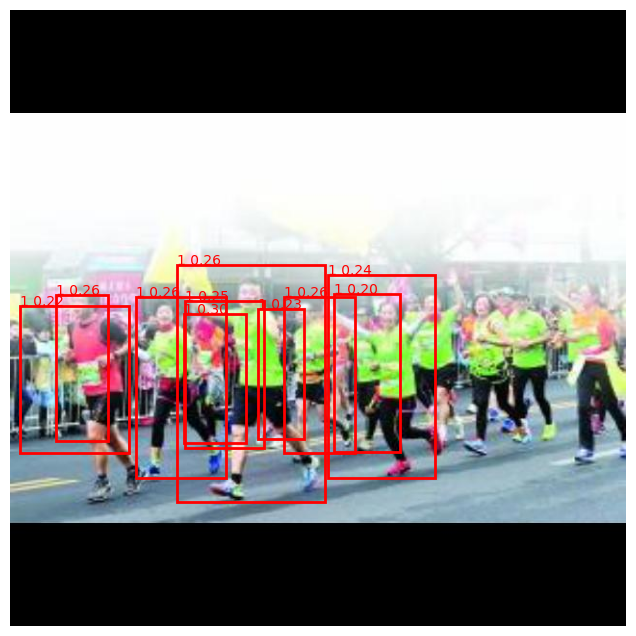

Image: 003617_jpg.rf.7f822fe1bc9f7b7be4c742f7e6e6d611.jpg
Predicted labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
Scores: tensor([0.2984, 0.2641, 0.2621, 0.2585, 0.2559, 0.2458, 0.2411, 0.2258, 0.2192,
        0.2014], device='cuda:0')


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch, os, random

img_info = random.choice(val_data["images"])
img_path = os.path.join(VAL_IMG, img_info["file_name"])

image = Image.open(img_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

preds = processor.post_process_object_detection(
    outputs,
    threshold=0.2,
    target_sizes=target_sizes
)[0]

plt.figure(figsize=(10, 8))
plt.imshow(image)
ax = plt.gca()

for score, label, box in zip(preds["scores"], preds["labels"], preds["boxes"]):
    x1, y1, x2, y2 = box.cpu().numpy()
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="r",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1, y1, f"{label.item()} {score.item():.2f}", color="red")

plt.axis("off")
plt.show()

print("Image:", img_info["file_name"])
print("Predicted labels:", preds["labels"])
print("Scores:", preds["scores"])


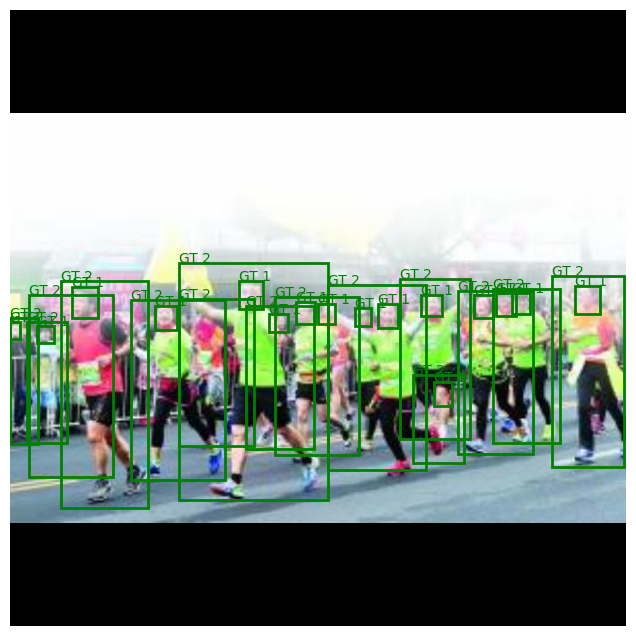

GT labels: [2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2]


In [ ]:
anns = [a for a in val_data["annotations"] if a["image_id"] == img_info["id"]]

plt.figure(figsize=(10, 8))
plt.imshow(image)
ax = plt.gca()

for ann in anns:
    x, y, w, h = ann["bbox"]
    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        edgecolor="g",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x, y, f"GT {ann['category_id']}", color="green")

plt.axis("off")
plt.show()

print("GT labels:", [a["category_id"] for a in anns])

In [6]:
import os, json, torch, random
from torch.utils.data import DataLoader, Dataset, Subset
from transformers import AutoModelForObjectDetection, AutoImageProcessor
from PIL import Image

# ── Config ───────────────────────────────────────────────
EXPERIMENT   = "wilderperson"
DATASET      = "wilderperson_coco"
BASE         = "/content/final-year-research"
DRIVE_OUT    = "/content/drive/MyDrive/final-year-research/runs"

EPOCHS       = 30          # 40 more on top of your existing 30
BATCH_SIZE   = 16
LR           = 2e-5        # lower LR for fine-tuning from checkpoint
SUBSET_FRAC  = 0.4         # use 30% of data — balance speed vs coverage
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

IMAGES_TRAIN = f"{BASE}/{DATASET}/train"
TRAIN_JSON   = f"{BASE}/{DATASET}/coco.train.json"
CHECKPOINT   = f"{DRIVE_OUT}/rtdetr_{EXPERIMENT}/best"   # ← resume from here
SAVE_PATH    = f"{DRIVE_OUT}/rtdetr_{EXPERIMENT}"

CATEGORY_REMAP = {1: 0, 2: 1}
ID2LABEL = {0: "head", 1: "person"}
LABEL2ID = {"head": 0, "person": 1}
# ────────────────────────────────────────────────────────

os.makedirs(f"{SAVE_PATH}/best", exist_ok=True)
os.makedirs(f"{SAVE_PATH}/last", exist_ok=True)

# ── Load from checkpoint ─────────────────────────────────
print("Loading from checkpoint...")
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)
print(f"✓ Checkpoint loaded on {DEVICE}")


class COCODataset(Dataset):
    def __init__(self, images_dir, json_path, processor):
        self.images_dir = images_dir
        self.processor  = processor

        with open(json_path) as f:
            coco = json.load(f)

        self.images  = {img["id"]: img for img in coco["images"]}
        self.img_ids = list(self.images.keys())
        self.anns    = {img_id: [] for img_id in self.img_ids}

        for ann in coco["annotations"]:
            self.anns[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.images[img_id]
        image    = Image.open(
            os.path.join(self.images_dir, img_info["file_name"])
        ).convert("RGB")

        anns = self.anns[img_id]
        target = {"image_id": img_id, "annotations": [
            {
                "bbox": a["bbox"],
                "category_id": CATEGORY_REMAP.get(a["category_id"], a["category_id"]),
                "iscrowd": 0,
                "area": a["bbox"][2] * a["bbox"][3]
            }
            for a in anns
        ]}

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt"
        )

        # ── Fix: only squeeze tensors, skip lists ────────────
        return {
            k: v.squeeze(0) if isinstance(v, torch.Tensor) else v
            for k, v in encoding.items()
        }


def collate_fn(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "labels": [b["labels"] if isinstance(b["labels"], dict)
                   else b["labels"][0] if isinstance(b["labels"], list) and len(b["labels"]) > 0
                   else {}
                   for b in batch]
    }


# ── Subset ───────────────────────────────────────────────
full_ds    = COCODataset(IMAGES_TRAIN, TRAIN_JSON, processor)
subset_idx = random.sample(range(len(full_ds)), int(SUBSET_FRAC * len(full_ds)))
train_ds   = Subset(full_ds, subset_idx)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)

print(f"✓ Using {len(train_ds)}/{len(full_ds)} images ({int(SUBSET_FRAC*100)}% subset)")

# ── Optimizer with warmup + cosine decay ─────────────────
optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
total_steps  = EPOCHS * len(train_loader)
warmup_steps = 2 * len(train_loader)   # 2 epoch warmup

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)).item())

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Training Loop ────────────────────────────────────────
best_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels = [{k: v.to(DEVICE) for k, v in t.items()}
                  for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if i % 50 == 0:
            print(f"  Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} — Avg Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        model.save_pretrained(f"{SAVE_PATH}/best")
        processor.save_pretrained(f"{SAVE_PATH}/best")
        print(f"  ✓ Best model saved (loss: {best_loss:.4f})")

model.save_pretrained(f"{SAVE_PATH}/last")
processor.save_pretrained(f"{SAVE_PATH}/last")
print("✓ Training complete.")

Loading from checkpoint...


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

✓ Checkpoint loaded on cuda
✓ Using 4039/10098 images (40% subset)
  Epoch 1 | Step 0/253 | Loss: 4.9180 | LR: 3.95e-08
  Epoch 1 | Step 50/253 | Loss: 4.7734 | LR: 2.02e-06
  Epoch 1 | Step 100/253 | Loss: 5.0443 | LR: 3.99e-06
  Epoch 1 | Step 150/253 | Loss: 4.5795 | LR: 5.97e-06
  Epoch 1 | Step 200/253 | Loss: 5.3649 | LR: 7.94e-06
  Epoch 1 | Step 250/253 | Loss: 4.7500 | LR: 9.92e-06
Epoch 1/30 — Avg Loss: 4.6939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (loss: 4.6939)
  Epoch 2 | Step 0/253 | Loss: 4.8212 | LR: 1.00e-05
  Epoch 2 | Step 50/253 | Loss: 4.8418 | LR: 1.20e-05
  Epoch 2 | Step 100/253 | Loss: 4.3446 | LR: 1.40e-05
  Epoch 2 | Step 150/253 | Loss: 4.5743 | LR: 1.60e-05
  Epoch 2 | Step 200/253 | Loss: 4.7581 | LR: 1.79e-05
  Epoch 2 | Step 250/253 | Loss: 4.8574 | LR: 1.99e-05
Epoch 2/30 — Avg Loss: 4.6623


...

  ✓ Best model saved (loss: 4.0151)
  Epoch 28 | Step 0/253 | Loss: 4.1352 | LR: 5.60e-07
  Epoch 28 | Step 50/253 | Loss: 3.9901 | LR: 4.89e-07
  Epoch 28 | Step 100/253 | Loss: 3.8622 | LR: 4.23e-07
  Epoch 28 | Step 150/253 | Loss: 3.8319 | LR: 3.61e-07
  Epoch 28 | Step 200/253 | Loss: 4.0715 | LR: 3.05e-07
  Epoch 28 | Step 250/253 | Loss: 3.7855 | LR: 2.53e-07
Epoch 28/30 — Avg Loss: 4.0204
  Epoch 29 | Step 0/253 | Loss: 4.2051 | LR: 2.50e-07
  Epoch 29 | Step 50/253 | Loss: 3.9338 | LR: 2.03e-07
  Epoch 29 | Step 100/253 | Loss: 3.4904 | LR: 1.61e-07
  Epoch 29 | Step 150/253 | Loss: 4.3629 | LR: 1.24e-07
  Epoch 29 | Step 200/253 | Loss: 4.2692 | LR: 9.13e-08
  Epoch 29 | Step 250/253 | Loss: 3.7564 | LR: 6.39e-08
Epoch 29/30 — Avg Loss: 4.0262
  Epoch 30 | Step 0/253 | Loss: 3.6372 | LR: 6.24e-08
  Epoch 30 | Step 50/253 | Loss: 3.9496 | LR: 4.01e-08
  Epoch 30 | Step 100/253 | Loss: 3.8155 | LR: 2.27e-08
  Epoch 30 | Step 150/253 | Loss: 4.0032 | LR: 1.02e-08
  Epoch 30 | St

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (loss: 4.0142)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Training complete.


In [14]:
from transformers import AutoModelForObjectDetection, AutoImageProcessor
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import torch, json, os
from PIL import Image

# ── Config ───────────────────────────────────────────────
EXPERIMENT = "wilderperson"
DATASET    = "wilderperson_coco"
BASE       = "/content/final-year-research"
DRIVE_OUT  = "/content/drive/MyDrive/final-year-research/runs"

SAVE_PATH  = f"{DRIVE_OUT}/rtdetr_{EXPERIMENT}/best"
VAL_JSON   = f"{BASE}/{DATASET}/coco.valid.json"
VAL_IMG    = f"{BASE}/{DATASET}/valid"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

LABEL_REMAP = {0: 1, 1: 2}        # reverse of training remap
# ────────────────────────────────────────────────────────

processor = AutoImageProcessor.from_pretrained(SAVE_PATH)
model     = AutoModelForObjectDetection.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()

with open(VAL_JSON) as f:
    val_data = json.load(f)

coco_gt = COCO(VAL_JSON)
results = []

print(f"Running inference on {len(val_data['images'])} images...")

for idx, img_info in enumerate(val_data["images"]):
    image = Image.open(
        os.path.join(VAL_IMG, img_info["file_name"])
    ).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)
    preds = processor.post_process_object_detection(
        outputs, threshold=0.05,        # lowered from 0.5 — catches more detections
        target_sizes=target_sizes
    )[0]

    for score, label, box in zip(
        preds["scores"], preds["labels"], preds["boxes"]
    ):
        x1, y1, x2, y2 = box.tolist()
        results.append({
            "image_id":    img_info["id"],
            "category_id": LABEL_REMAP.get(label.item(), label.item()),
            "bbox":        [x1, y1, x2 - x1, y2 - y1],
            "score":       score.item()
        })

    if idx % 500 == 0:
        print(f"  {idx}/{len(val_data['images'])} done...")

# ── COCO Evaluation ──────────────────────────────────────
if len(results) == 0:
    print("⚠ No detections — try threshold=0.1")
else:
    print(f"Total detections: {len(results)}")
    coco_dt   = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    print("\n── RT-DETR Results (Normal Baseline) ───")
    print(f"mAP50-95 : {coco_eval.stats[0]:.4f}")
    print(f"mAP50    : {coco_eval.stats[1]:.4f}")
    print(f"Recall   : {coco_eval.stats[8]:.4f}")
    print("─────────────────────────────────────────")

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.68s)
creating index...
index created!
Running inference on 3284 images...
  0/3284 done...
  500/3284 done...
  1000/3284 done...
  1500/3284 done...
  2000/3284 done...
  2500/3284 done...
  3000/3284 done...
Total detections: 152614
Loading and preparing results...
DONE (t=12.43s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=103.25s).
Accumulating evaluation results...
DONE (t=2.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.233
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.378
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.251
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.329
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.523
 Average Recall     (AR) 

Debugging

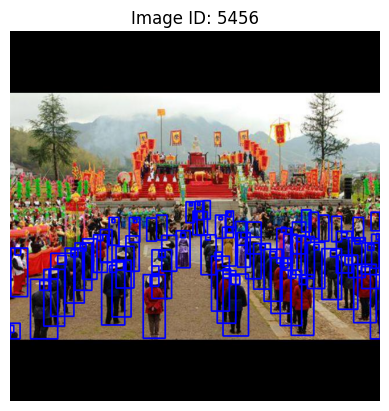

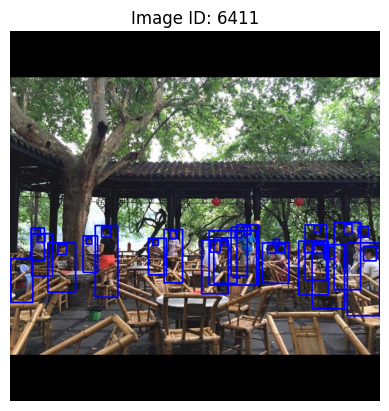

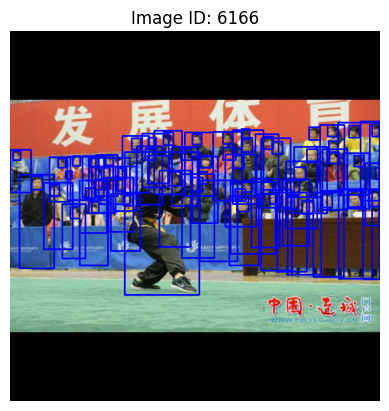

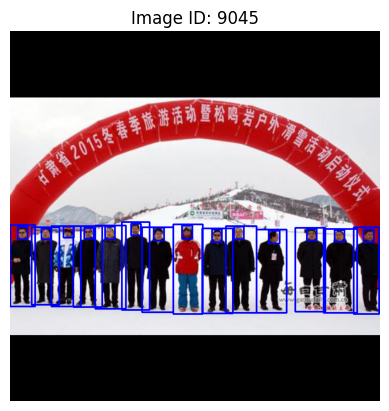

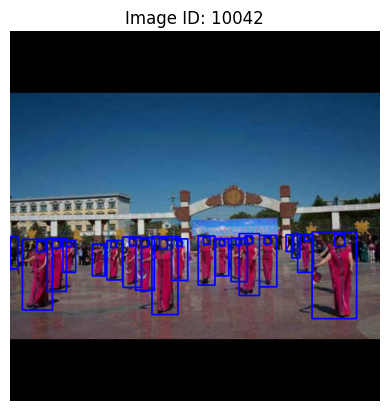

In [8]:
import json
import cv2
import random
import os
import matplotlib.pyplot as plt




# مسیر (update these)
IMAGE_DIR = "/content/final-year-research/wilderperson_coco/train"
ANNOTATION_FILE = "/content/final-year-research/wilderperson_coco/coco.train.json"

# Load COCO annotations
with open(ANNOTATION_FILE) as f:
    coco = json.load(f)

images = coco['images']
annotations = coco['annotations']

# Map image_id → annotations
ann_map = {}
for ann in annotations:
    ann_map.setdefault(ann['image_id'], []).append(ann)

# Pick random images
sample_images = random.sample(images, 5)

for img_info in sample_images:
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])
    img = cv2.imread(img_path)

    if img is None:
        continue

    img_id = img_info['id']
    anns = ann_map.get(img_id, [])

    for ann in anns:
        x, y, w, h = ann['bbox']
        x1, y1, x2, y2 = int(x), int(y), int(x+w), int(y+h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Image ID: {img_id}")
    plt.axis('off')
    plt.show()

In [9]:
img_id = 5456

anns = [a for a in val_data["annotations"] if a["image_id"] == img_id]

print("Number of GT boxes:", len(anns))

for a in anns[:10]:
    print(a["category_id"], a["bbox"])

Number of GT boxes: 0


In [11]:
image_ids = set(img["id"] for img in val_data["images"])
ann_image_ids = set(ann["image_id"] for ann in val_data["annotations"])

print("Images:", len(image_ids))
print("Annotation image IDs:", len(ann_image_ids))
print("Matching IDs:", len(image_ids & ann_image_ids))

print("First image IDs:", list(image_ids)[:10])
print("First annotation image IDs:", list(ann_image_ids)[:10])

Images: 3284
Annotation image IDs: 3284
Matching IDs: 3284
First image IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
First annotation image IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [12]:
img_id = 545   # example, must be between 0 and 3283

anns = [a for a in val_data["annotations"] if a["image_id"] == img_id]

print("Number of GT boxes:", len(anns))
print(anns[:5])

Number of GT boxes: 25
[{'id': 25354, 'image_id': 545, 'category_id': 2, 'bbox': [281, 263, 75, 124], 'area': 9300, 'segmentation': [], 'iscrowd': 0}, {'id': 25355, 'image_id': 545, 'category_id': 2, 'bbox': [296, 233, 55, 117], 'area': 6435, 'segmentation': [], 'iscrowd': 0}, {'id': 25356, 'image_id': 545, 'category_id': 2, 'bbox': [254, 247, 85, 174], 'area': 14790, 'segmentation': [], 'iscrowd': 0}, {'id': 25357, 'image_id': 545, 'category_id': 2, 'bbox': [461, 242, 94, 162], 'area': 15228, 'segmentation': [], 'iscrowd': 0}, {'id': 25358, 'image_id': 545, 'category_id': 2, 'bbox': [1, 218, 80, 140], 'area': 11200, 'segmentation': [], 'iscrowd': 0}]


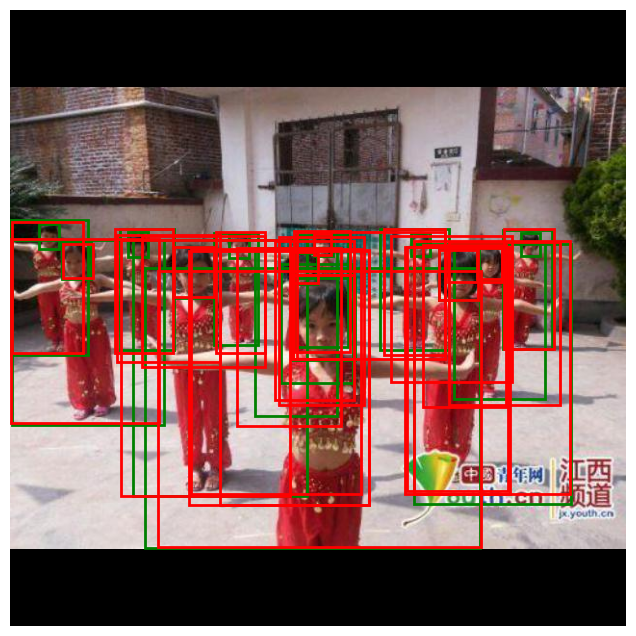

GT count: 25
Prediction count: 36
Prediction labels: tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       device='cuda:0')
Scores: tensor([0.4162, 0.3518, 0.3465, 0.3416, 0.3273, 0.2890, 0.2472, 0.2283, 0.2106,
        0.1825, 0.1800, 0.1744, 0.1727, 0.1597, 0.1504, 0.1405, 0.1346, 0.1234,
        0.1212, 0.1199], device='cuda:0')


In [13]:
img_id = 545

img_info = next(img for img in val_data["images"] if img["id"] == img_id)
img_path = os.path.join(VAL_IMG, img_info["file_name"])

image = Image.open(img_path).convert("RGB")

# predictions
inputs = processor(images=image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

preds = processor.post_process_object_detection(
    outputs,
    threshold=0.05,
    target_sizes=target_sizes
)[0]

# ground truth
anns = [a for a in val_data["annotations"] if a["image_id"] == img_id]

plt.figure(figsize=(10, 8))
plt.imshow(image)
ax = plt.gca()

# GT boxes = green
for ann in anns:
    x, y, w, h = ann["bbox"]
    ax.add_patch(patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor="green",
        facecolor="none"
    ))

# Prediction boxes = red
for score, label, box in zip(preds["scores"], preds["labels"], preds["boxes"]):
    x1, y1, x2, y2 = box.cpu().numpy()
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    ))

plt.axis("off")
plt.show()

print("GT count:", len(anns))
print("Prediction count:", len(preds["boxes"]))
print("Prediction labels:", preds["labels"][:20])
print("Scores:", preds["scores"][:20])